In [1]:
!pip install pandas numpy matplotlib seaborn prophet pyarrow scikit-learn

In [2]:
import pandas as pd
import numpy as np

url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2020-01.parquet"

df = pd.read_parquet(url)

# Keep only required columns
df = df[[
    "tpep_pickup_datetime",
    "trip_distance",
    "PULocationID",
    "DOLocationID",
    "total_amount"
]]

df = df.dropna()

print(df.head())
print(df.shape)

  tpep_pickup_datetime  trip_distance  PULocationID  DOLocationID  \
0  2020-01-01 00:28:15            1.2           238           239   
1  2020-01-01 00:35:39            1.2           239           238   
2  2020-01-01 00:47:41            0.6           238           238   
3  2020-01-01 00:55:23            0.8           238           151   
4  2020-01-01 00:01:58            0.0           193           193   

   total_amount  
0         11.27  
1         12.30  
2         10.80  
3          8.16  
4          4.80  
(6405008, 5)


In [3]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

df['date'] = df['tpep_pickup_datetime'].dt.date
df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek

# Demand = number of trips per day (logistics proxy)
demand = df.groupby('date').size().reset_index(name='demand')

demand.columns = ['ds', 'y']

print(demand.head())

           ds    y
0  2003-01-01    1
1  2008-12-31   10
2  2009-01-01   19
3  2019-12-18    2
4  2019-12-31  129


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


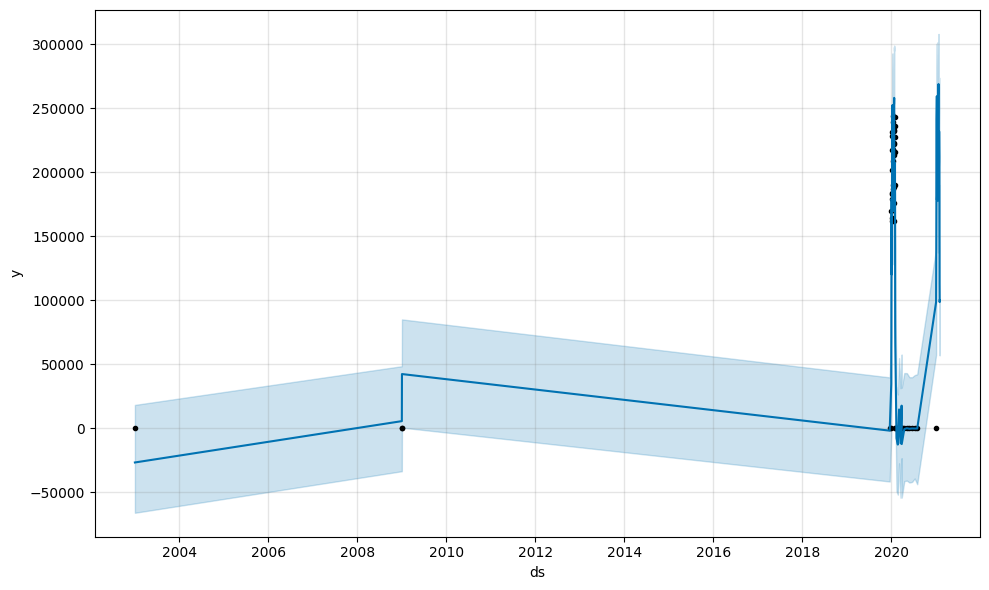

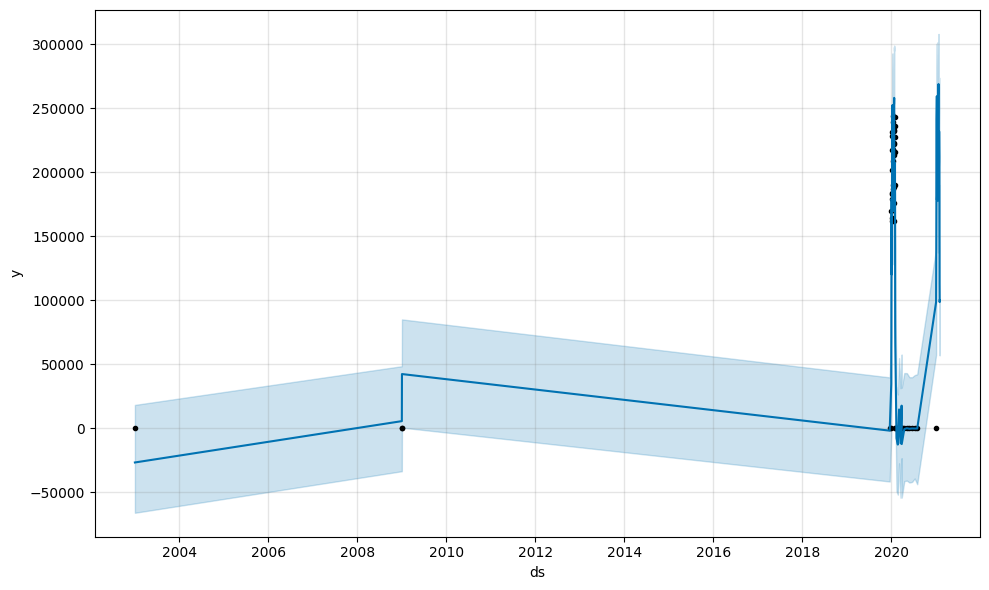

In [4]:
from prophet import Prophet

model = Prophet()
model.fit(demand)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

model.plot(forecast)

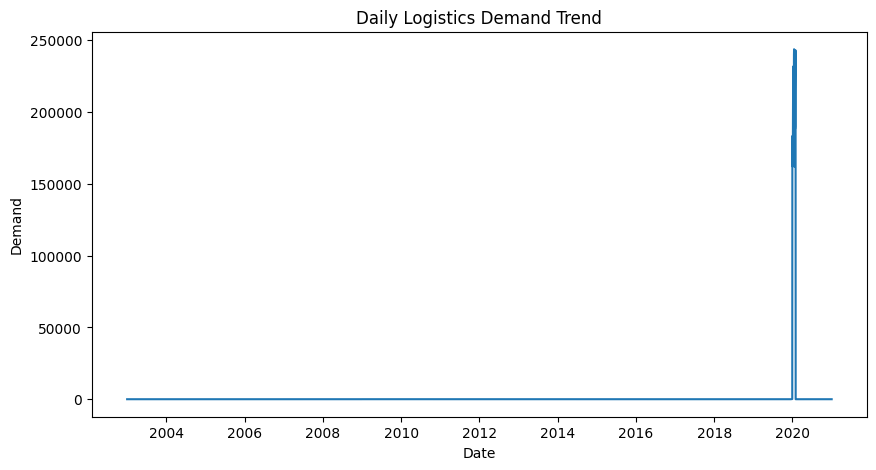

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(demand['ds'], demand['y'])
plt.title("Daily Logistics Demand Trend")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

df_ml = df.copy()

df_ml['target'] = 1  # each row = delivery event

features = ['hour', 'day_of_week', 'trip_distance']

X = df_ml[features]
y = df_ml['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model_ml = RandomForestRegressor(n_estimators=50)
model_ml.fit(X_train, y_train)

print("Model Score:", model_ml.score(X_test, y_test))

Model Score: 1.0


In [7]:
zone_demand = df.groupby('PULocationID').size().reset_index(name='demand')

zone_demand = zone_demand.sort_values(by='demand', ascending=False)

print(zone_demand.head(10))

     PULocationID  demand
232           237  292989
157           161  282213
231           236  272592
158           162  235602
182           186  228746
225           230  228553
128           132  214221
166           170  195027
47             48  194173
138           142  193689


In [8]:
def cost_function(distance, demand):
    return (distance * 0.6) + (demand * 0.4)

df['cost'] = cost_function(df['trip_distance'], 1)

optimized_routes = df.sort_values(by='cost').head(10)

print(optimized_routes[['trip_distance', 'cost']].head())

         trip_distance    cost
6355612         -30.62 -17.972
6355613         -30.62 -17.972
6378261         -29.47 -17.282
6341867         -29.23 -17.138
6358534         -29.10 -17.060
